In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [11]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/Trolley.csv", separator=";").select(
    "response", "id", "age", "male", "edu", "action", "intention", "contact", "story"
).with_columns(education=pl.col("edu").cast(pl.Categorical),
               story=pl.col("story").cast(pl.Categorical),
               id=pl.col("id").cast(pl.Categorical))

In [3]:
# get priors for cumulative log odds for cutpoints
cutpoint_priors = df.group_by("response").len().sort("response").with_columns(cumulative_probs=pl.col("len").cum_sum()/len(df))
cutpoint_priors = cutpoint_priors.with_columns(cumulative_log_odds=(pl.col("cumulative_probs")/(1-pl.col("cumulative_probs"))).log())
cutpoint_priors

response,len,cumulative_probs,cumulative_log_odds
i64,u32,f64,f64
1,1274,0.128298,-1.916091
2,909,0.219839,-1.266606
3,1071,0.327694,-0.718634
4,2323,0.561631,0.247786
5,1462,0.708862,0.889864
6,1445,0.854381,1.769381
7,1446,1.0,inf


In [4]:
with pm.Model(coords={
    "id": df["id"].unique()
}) as m_ordered_logit:
    # define data
    action = pm.Data("action", df["action"].to_numpy())
    intention = pm.Data("intention", df["intention"].to_numpy())
    contact = pm.Data("contact", df["contact"].to_numpy())
    individual = pm.Data("individual", df["id"].to_physical().to_numpy())

    # Priors for linear model coefficients
    b_action = pm.Normal("b_action", 0, 1)
    b_intention = pm.Normal("b_intention", 0, 1)
    b_contact = pm.Normal("b_contact", 0, 1)

    # priors for individuals
    individual_bias = pm.Normal("individual_bias", 0, 0.5, dims="id")

    # Linear model (phi) - represents the latent tendency
    phi = (
            b_action * action
           + b_intention * intention
           + b_contact * contact
           + individual_bias[individual]
           )

    # Cutpoints - these are the thresholds between ordered categories
    # We need K-1 cutpoints for K categories (response is 1-7, so 6 cutpoints)
    # Use ordered transform to ensure cutpoints are increasing
    cutpoints = pm.Normal("cutpoints",
                          mu=cutpoint_priors["cumulative_log_odds"].to_numpy()[:-1],
                          sigma=1.5,
                          transform=pm.distributions.transforms.ordered)

    # Likelihood using OrderedLogistic
    # Note: PyMC's OrderedLogistic takes eta (linear predictor) and cutpoints
    # The cumulative logit link: P(Y <= k) = logit^-1(cutpoints[k] - eta)
    response_obs = pm.OrderedLogistic("response_obs",
                                       eta=phi,  # linear predictor
                                       cutpoints=cutpoints,
                                       observed=df["response"].to_numpy()-1)

    # Sample from posterior
    posterior = pm.sample(draws=1000, chains=4)
    pm.compute_log_likelihood(posterior)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b_action, b_intention, b_contact, individual_bias, cutpoints]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 61 seconds.


Output()

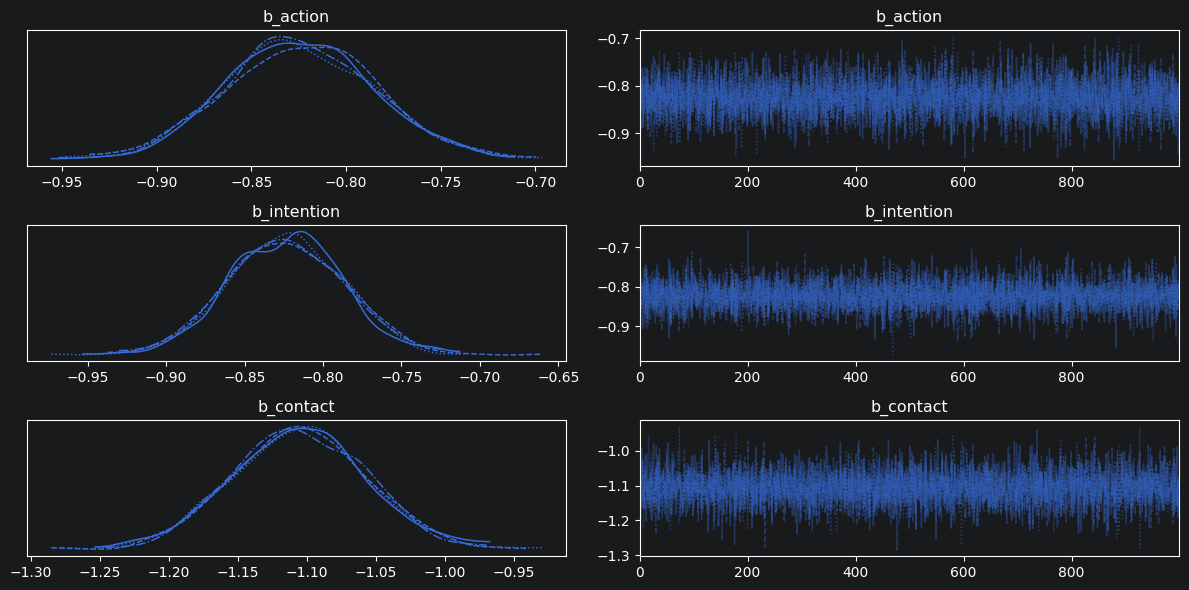

In [5]:
plot_trace(posterior, var_names=["b_action", "b_intention", "b_contact"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b_action, b_intention, b_contact, cutpoints]


Output()

/Users/voutrata/Projects/pymc-resources/.venv/lib/python3.10/site-packages/pytensor/compile/function/types.py:1039: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 31 seconds.


Output()

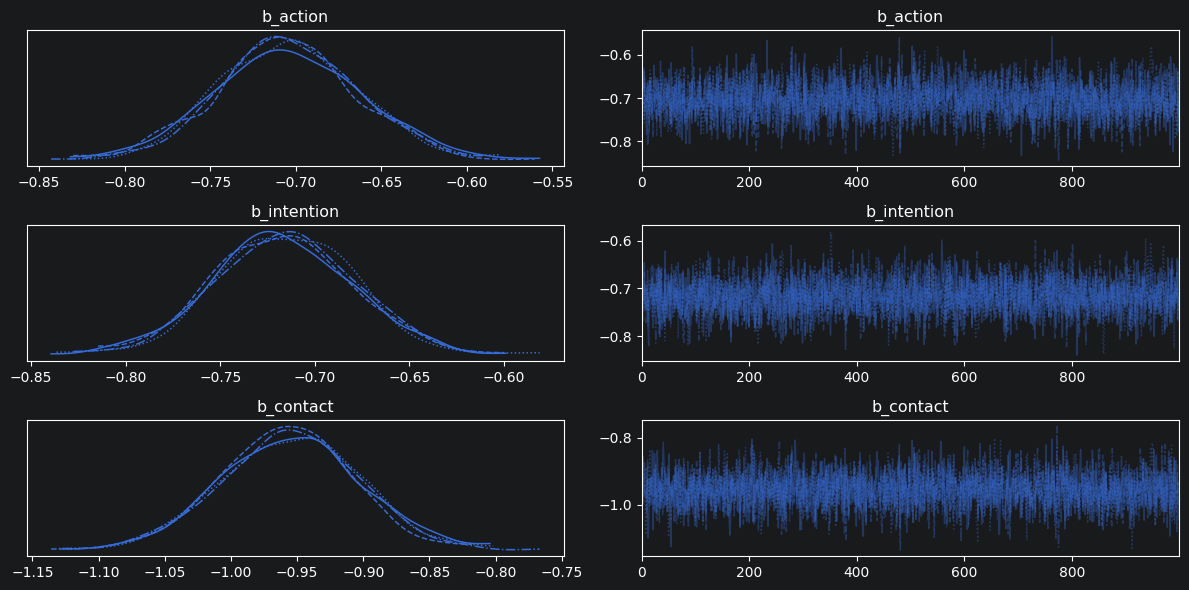

In [6]:
with pm.Model(coords={
    "id": df["id"].unique()
}) as m_ordered_logit:
    # define data
    action = pm.Data("action", df["action"].to_numpy())
    intention = pm.Data("intention", df["intention"].to_numpy())
    contact = pm.Data("contact", df["contact"].to_numpy())
    individual = pm.Data("individual", df["id"].to_physical().to_numpy())

    # Priors for linear model coefficients
    b_action = pm.Normal("b_action", 0, 1)
    b_intention = pm.Normal("b_intention", 0, 1)
    b_contact = pm.Normal("b_contact", 0, 1)

    # Linear model (phi) - represents the latent tendency
    phi = (
            b_action * action
           + b_intention * intention
           + b_contact * contact
           )

    # Cutpoints - these are the thresholds between ordered categories
    # We need K-1 cutpoints for K categories (response is 1-7, so 6 cutpoints)
    # Use ordered transform to ensure cutpoints are increasing
    cutpoints = pm.Normal("cutpoints",
                          mu=cutpoint_priors["cumulative_log_odds"].to_numpy()[:-1],
                          sigma=1.5,
                          transform=pm.distributions.transforms.ordered)

    # Likelihood using OrderedLogistic
    # Note: PyMC's OrderedLogistic takes eta (linear predictor) and cutpoints
    # The cumulative logit link: P(Y <= k) = logit^-1(cutpoints[k] - eta)
    response_obs = pm.OrderedLogistic("response_obs",
                                       eta=phi,  # linear predictor
                                       cutpoints=cutpoints,
                                       observed=df["response"].to_numpy()-1)

    # Sample from posterior
    posterior_2 = pm.sample(draws=1000, chains=4)
    pm.compute_log_likelihood(posterior_2)

plot_trace(posterior_2, var_names=["b_action", "b_intention", "b_contact"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b_action, b_intention, b_contact, individual_bias, story_bias, cutpoints]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 113 seconds.


Output()

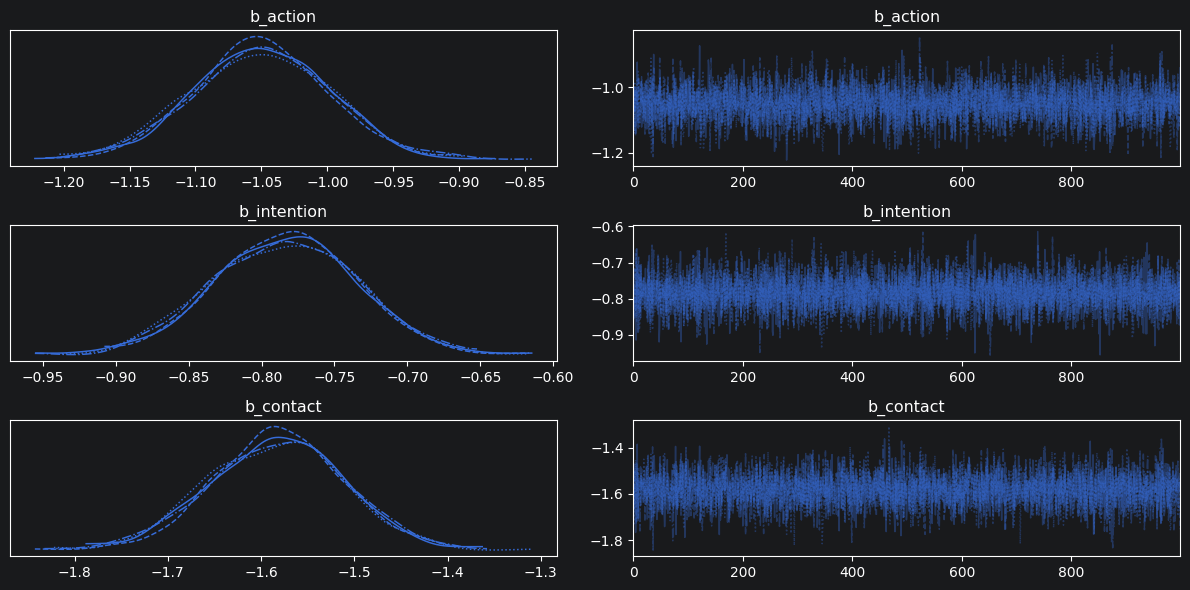

In [14]:
with pm.Model(coords={
    "id": df["id"].unique(),
    "story": df["story"].unique()
}) as m_ordered_logit:
    # define data
    action = pm.Data("action", df["action"].to_numpy())
    intention = pm.Data("intention", df["intention"].to_numpy())
    contact = pm.Data("contact", df["contact"].to_numpy())
    individual = pm.Data("individual", df["id"].to_physical().to_numpy())
    story = pm.Data("story", df["story"].to_physical().to_numpy())

    # Priors for linear model coefficients
    b_action = pm.Normal("b_action", 0, 1)
    b_intention = pm.Normal("b_intention", 0, 1)
    b_contact = pm.Normal("b_contact", 0, 1)

    # priors for individuals
    individual_bias = pm.Normal("individual_bias", 0, 0.5, dims="id")
    story_bias = pm.Normal("story_bias", 0, 0.5, dims="story")

    # Linear model (phi) - represents the latent tendency
    phi = (
            b_action * action
           + b_intention * intention
           + b_contact * contact
           + individual_bias[individual]
            + story_bias[story]
           )

    # Cutpoints - these are the thresholds between ordered categories
    # We need K-1 cutpoints for K categories (response is 1-7, so 6 cutpoints)
    # Use ordered transform to ensure cutpoints are increasing
    cutpoints = pm.Normal("cutpoints",
                          mu=cutpoint_priors["cumulative_log_odds"].to_numpy()[:-1],
                          sigma=1.5,
                          transform=pm.distributions.transforms.ordered)

    # Likelihood using OrderedLogistic
    # Note: PyMC's OrderedLogistic takes eta (linear predictor) and cutpoints
    # The cumulative logit link: P(Y <= k) = logit^-1(cutpoints[k] - eta)
    response_obs = pm.OrderedLogistic("response_obs",
                                       eta=phi,  # linear predictor
                                       cutpoints=cutpoints,
                                       observed=df["response"].to_numpy()-1)

    # Sample from posterior
    posterior_3 = pm.sample(draws=1000, chains=4)
    pm.compute_log_likelihood(posterior_3)

plot_trace(posterior_3, var_names=["b_action", "b_intention", "b_contact"])

In [15]:
comparison = az.compare({
    "basic": posterior_2,
    "multilevel": posterior,
    "multivel_twice": posterior_3
}, scale="deviance")
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
multivel_twice,0,31655.681870,226.827710,0.000000,1.000000,119.595924,0.000000,False,deviance
multilevel,1,32231.309409,221.919409,575.627539,0.000772,118.181244,40.566025,False,deviance
basic,2,37089.843040,8.978169,5434.161170,0.000000,76.038855,106.848391,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

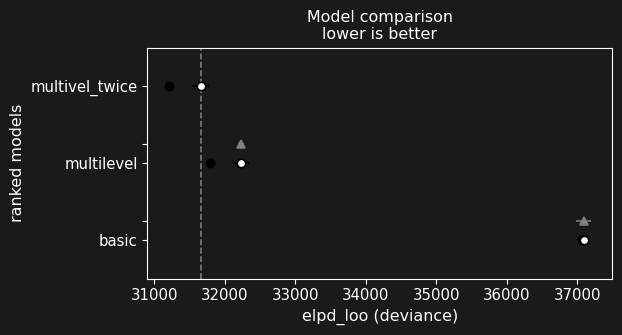

In [16]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)